# Cleaning and Forming Datasets

In this notebook, we perform some brief data cleaning, handling missing values.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
df = pd.read_csv("../Data/djok_data.csv")

In [60]:
df.head()

,Series,Surface,Round,dj_win,dj_rank,opp_rank,dj_pts,opp_pts,dj_odds,opp_odds,is_outdoor,is_five_sets,age_c,age_c_sq,five_sma,surface_form_last_20,head_to_head_rate,matches_last_30
0,ATP250,Clay,1st Round,0,368,65,-1,-1,5.50,1.12,1,0,-10.498852,110.225899,NaN,NaN,NaN,0
1,ATP250,Clay,1st Round,1,272,67,-1,-1,2.35,1.53,1,0,-10.345533,107.030045,0.000000,0.0,0.000000,0
2,ATP250,Clay,2nd Round,0,272,54,-1,-1,3.50,1.28,1,0,-10.340057,106.916777,0.500000,0.5,0.500000,1
3,ATP250,Hard,1st Round,0,248,81,-1,-1,2.20,1.61,0,0,-10.307203,106.238428,0.333333,NaN,0.333333,2
4,Grand Slam,Hard,1st Round,0,188,4,-1,-1,7.50,1.07,1,1,-10.003301,100.066036,0.250000,0.0,0.250000,0


In [61]:
print(f"Shape of dataset {df.shape}")

Shape of dataset (1267, 18)


## 1. Missing Values

To begin our analysis, let us do the usual checks of the data types of each column and null counts for each column.

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Series                1267 non-null   str    
 1   Surface               1267 non-null   str    
 2   Round                 1267 non-null   str    
 3   dj_win                1267 non-null   int64  
 4   dj_rank               1267 non-null   int64  
 5   opp_rank              1267 non-null   int64  
 6   dj_pts                1267 non-null   int64  
 7   opp_pts               1267 non-null   int64  
 8   dj_odds               1267 non-null   float64
 9   opp_odds              1267 non-null   float64
 10  is_outdoor            1267 non-null   int64  
 11  is_five_sets          1267 non-null   int64  
 12  age_c                 1267 non-null   float64
 13  age_c_sq              1267 non-null   float64
 14  five_sma              1266 non-null   float64
 15  surface_form_last_20  1264 non-n

We see that we have $1267$ matches/rows, and most of the variables have $1267$ non-null entries. However, we see that the five match moving average has $1266$ non-null entries, the $20$-match surface form has $1264$ non-null entries and the head to head rate has $1266$ non-null entries.

Let us first locate the match where the moving average is NULL.

In [63]:
df.loc[df["five_sma"].isnull()]

,Series,Surface,Round,dj_win,dj_rank,opp_rank,dj_pts,opp_pts,dj_odds,opp_odds,is_outdoor,is_five_sets,age_c,age_c_sq,five_sma,surface_form_last_20,head_to_head_rate,matches_last_30
0,ATP250,Clay,1st Round,0,368,65,-1,-1,5.5,1.12,1,0,-10.498852,110.225899,NaN,NaN,NaN,0


The index being zero here indicates this is the first ever match in Djokovic's career. It makes sense to have a null value here since we have no previous data to work with. We can also see that the surface form here is null, and the same with the head to head rate.

In a similar sense, since the surface form column has three null values, this will be because there are three surfaces in our dataset, so there will be three occasions where Djokovic plays on a surface for the first time and for each of these occasions there will be no previous matches to derive the information from. Let us check this hypothesis.

In [64]:
df.sort_values("age_c").groupby("Surface").head(1)[["Surface", "surface_form_last_20"]]

,Surface,surface_form_last_20
0,Clay,NaN
3,Hard,NaN
7,Grass,NaN


Our check above extracts the first match on each surface and extract the surface form value for these matches. We see these are the null values, confirming the hypothesis.

Since we only have $3$ matches overall with null values (the head to head, five match average, and one fo the surface nulls fall on the first match of his career), and we have plenty more data to work with, we will simply drop these matches.

In [65]:
df = df.dropna()

In [66]:
df.info()

<class 'pandas.DataFrame'>
Index: 1264 entries, 1 to 1266
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Series                1264 non-null   str    
 1   Surface               1264 non-null   str    
 2   Round                 1264 non-null   str    
 3   dj_win                1264 non-null   int64  
 4   dj_rank               1264 non-null   int64  
 5   opp_rank              1264 non-null   int64  
 6   dj_pts                1264 non-null   int64  
 7   opp_pts               1264 non-null   int64  
 8   dj_odds               1264 non-null   float64
 9   opp_odds              1264 non-null   float64
 10  is_outdoor            1264 non-null   int64  
 11  is_five_sets          1264 non-null   int64  
 12  age_c                 1264 non-null   float64
 13  age_c_sq              1264 non-null   float64
 14  five_sma              1264 non-null   float64
 15  surface_form_last_20  1264 non-null  

We see now that we have $1264$ matches overall, so the null values have correctly been dropped. Let us move on to analysing the numeric columns.

## 2. Numeric Checks

Let us now understand the statistical description of each of the numeric values.

In [67]:
df.describe().round(2)

,dj_win,dj_rank,opp_rank,dj_pts,opp_pts,dj_odds,opp_odds,is_outdoor,is_five_sets,age_c,age_c_sq,five_sma,surface_form_last_20,head_to_head_rate,matches_last_30
count,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.00,1264.0
mean,0.84,5.78,48.61,8708.91,2394.53,1.41,9.36,0.86,0.35,0.10,32.29,0.84,0.84,0.77,5.8
std,0.36,17.70,76.25,4181.84,2594.97,1.81,8.73,0.35,0.48,5.68,32.04,0.16,0.12,0.24,3.3
min,0.00,1.00,1.00,-1.00,-1.00,1.00,0.97,0.00,0.00,-10.35,0.00,0.00,0.00,0.00,0.0
25%,1.00,1.00,9.00,5070.00,767.75,1.04,3.50,1.00,0.00,-4.71,4.82,0.80,0.80,0.67,3.0
50%,1.00,2.00,30.00,9160.00,1305.00,1.11,6.50,1.00,0.00,-0.39,21.26,0.80,0.85,0.83,6.0
75%,1.00,3.00,64.00,11855.75,3137.50,1.28,11.00,1.00,1.00,4.48,53.91,1.00,0.90,1.00,8.0
max,1.00,272.00,1543.00,16950.00,15360.00,34.00,67.00,1.00,1.00,11.47,131.62,1.00,1.00,1.00,16.0


Most things here look fine. However, we see that we have $-1$ entries in the points columns which are impossible, and odds values that are less than (or equal to) one, which are also impossible since no rational person would ever bet on these odds, since winning would mean they lose money (or break even if odds of one). Let us first do some further analysis on the negative point entries. The smallest number of points a player on the ATP tour can have is zero, thus we check for any rows with negative point values.

In [68]:
n_minus = df[(df["dj_pts"] < 0) | (df["opp_pts"] < 0)].shape[0]

print(f"Number of rows that have negative point entries: {n_minus}")
print(f"Percentage of rows that have negative point entries: {n_minus / df.shape[0] * 100 :.4f}%")

Number of rows that have negative point entries: 7
Percentage of rows that have negative point entries: 0.5538%


In [69]:
n_imposs_odds = df[(df["dj_odds"] <= 1) | (df["opp_odds"] <= 1)].shape[0]

print(f"Number of rows that have impossible odds entries: {n_imposs_odds}")
print(f"Percentage of rows that have impossible odds entries: {n_imposs_odds / df.shape[0] * 100 :.4f}%")

Number of rows that have impossible odds entries: 18
Percentage of rows that have impossible odds entries: 1.4241%


Some of these missing/impossible values may actually fall on the same matches. It is informative to understand whether there is any overlap.

In [70]:
n_overall = df[(df["dj_odds"] <= 1) | (df["opp_odds"] <= 1) | (df["dj_pts"] < 0) | (df["opp_pts"] < 0)].shape[0]

print(f"Number of rows that have missing/impossible entries: {n_overall}")
print(f"Percentage of rows that have missing/impossible entries: {n_overall / df.shape[0] * 100 :.4f}%")

Number of rows that have missing/impossible entries: 25
Percentage of rows that have missing/impossible entries: 1.9778%


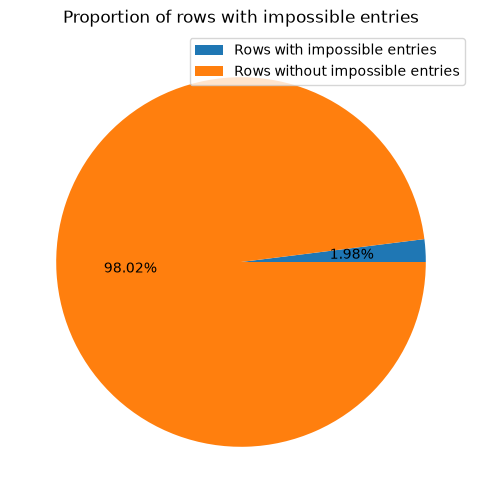

In [71]:
pie_data = pd.Series(
    [n_overall, df.shape[0] - n_overall],
    index=["Rows with impossible entries", "Rows without impossible entries"]
)

fig, ax = plt.subplots(figsize=(6, 6))
pie_data.plot.pie(ax=ax, autopct="%.2f%%", labels=None)
ax.legend(pie_data.index, loc="upper right")
ax.set_ylabel("")
plt.title("Proportion of rows with impossible entries")
plt.show()

Clearly, there is no overlap since the number of rows with any impossible value entry is equal to the sum of the number of rows with either one source of impossibility. The percentage of datapoints with such impossible entries is only $\approx 1.98\%$ of the entire dataset. We can just drop these rows since we still have sufficiently enough further data.

In [72]:
df = df[(df["dj_pts"] >= 0) & (df["opp_pts"] >= 0) & (df["dj_odds"] > 1) & (df["opp_odds"] > 1)]

In [73]:
verdicts = (df["dj_pts"].min() >= 0) & (df["opp_pts"] >= 0) & (df["dj_odds"] > 1) & (df["opp_odds"] > 1)
print(f"All rows with impossible entries have been removed: {verdicts.all()}")

All rows with impossible entries have been removed: True


In [74]:
df.shape[0]

1239

After dropping all of these matches, we are left with $1239$ remaining matches. Still plenty to work with.

## 3. Forming Datasets

This project is concerned with understanding the difference in model performances when trained on three different datasets. One with only odds data, one with only our chosen features, and one with both odds data and our features. We will now form our three datasets, including one-hot encoded versions, so six in total. When one-hot encoding, we drop one of the columns to prevent perfect multicollinearity with future intercept columns. This can lead to instability and inability to interpret coefficients. The dropped column becomes the baseline. Then, the coefficients become relative, for example the clay court coefficient in logistic regression will be interpreted as the change in log-odds when playing on clay relative to hard court.

In [75]:
encoded = pd.concat([pd.get_dummies(df["Series"]).drop(columns="ATP250").astype(int),
                    pd.get_dummies(df["Surface"]).drop(columns="Hard").astype(int),
                    pd.get_dummies(df["Round"]).drop(columns="1st Round").astype(int)], axis=1)

Having applied one-hot encoding to all categorical variables, we can now add these new columns to our dataset and drop the old categorical columns

In [78]:
df_enc = pd.concat([df, encoded], axis=1).drop(columns=["Series", "Surface", "Round"])

In [80]:
df_enc.head()

,dj_win,dj_rank,opp_rank,dj_pts,opp_pts,dj_odds,opp_odds,is_outdoor,is_five_sets,age_c,...,Masters Cup,Clay,Grass,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
10,1,97,163,417,259,1.36,2.87,1,0,-9.483110,...,0,1,0,0,0,0,0,0,0,0
11,0,97,28,417,1170,5.00,1.14,1,0,-9.480372,...,0,1,0,1,0,0,0,0,0,0
12,0,97,18,440,1385,3.50,1.28,1,0,-9.428353,...,0,0,0,0,0,0,0,0,0,0
13,1,97,43,431,825,2.50,1.50,1,1,-9.387285,...,0,0,0,0,0,0,0,0,0,0
14,1,97,24,431,1230,3.50,1.28,1,1,-9.379071,...,0,0,0,1,0,0,0,0,0,0


Now, we are ready for exporting.

In [82]:
df.to_csv("../Data/full_data.csv", index=False)
df_enc.to_csv("../Data/full_data_enc.csv", index=False)

df.drop(columns=["dj_odds", "opp_odds"]).to_csv("../Data/nodds_data.csv", index=False)
df_enc.drop(columns=["dj_odds", "opp_odds"]).to_csv("../Data/nodds_data_enc.csv", index=False)

df[["dj_odds", "opp_odds", "dj_win"]].to_csv("../Data/odds_data.csv", index=False)
df_enc[["dj_odds", "opp_odds", "dj_win"]].to_csv("../Data/odds_data_enc.csv", index=False)